# Day 10 – Model Metrics & Saved Model

## Objective

Compute model metrics and persist a trained model for later use.

---


In [29]:
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [30]:
data = pd.read_csv("student_scores_1.csv")

data

,Name,Hours_Studied,Final_Score,Previous_Score,Attendance
0,STU_001,4.4,67.0,58.0,85.0
1,STU_002,9.6,100.0,97.0,96.0
2,STU_003,7.6,89.9,86.0,91.0
3,STU_004,6.4,74.8,69.0,83.0
4,STU_005,2.4,48.4,42.0,81.0
...,...,...,...,...,...
497,STU_498,1.7,53.8,NaN,77.0
498,STU_499,9.8,100.0,99.0,91.0
499,STU_500,9.9,100.0,94.0,93.0
500,STU_021,6.5,73.0,65.0,88.0


In [31]:
data["Attendance"] = data["Attendance"].fillna(data["Attendance"].mean())
data["Previous_Score"] = data["Previous_Score"].fillna(data["Previous_Score"].mean())
data["Hours_Studied"] = data["Hours_Studied"].fillna(data["Hours_Studied"].mean())
data["Final_Score"] = data["Final_Score"].fillna(data["Final_Score"].mean())

In [32]:
X = data[["Hours_Studied", "Attendance", "Previous_Score"]]

y = data["Final_Score"]

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

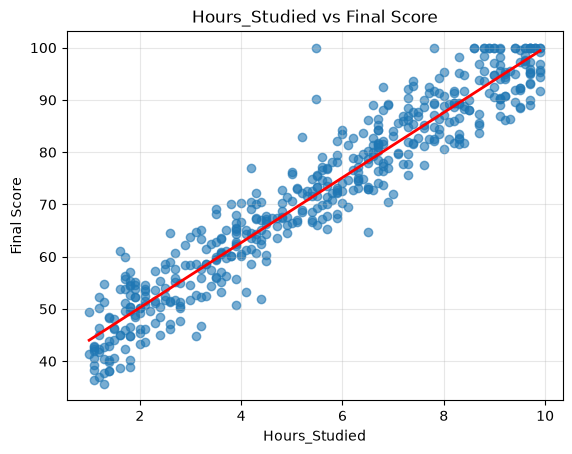

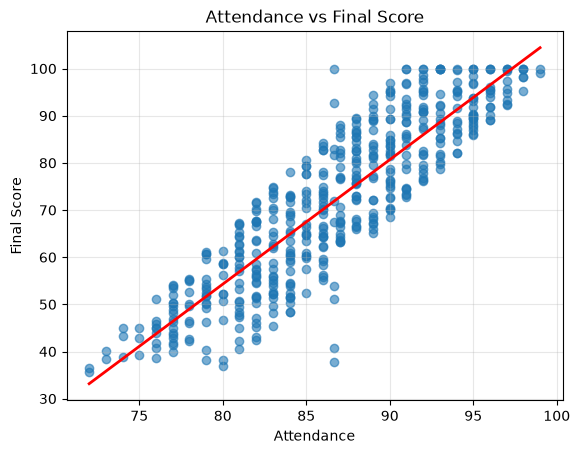

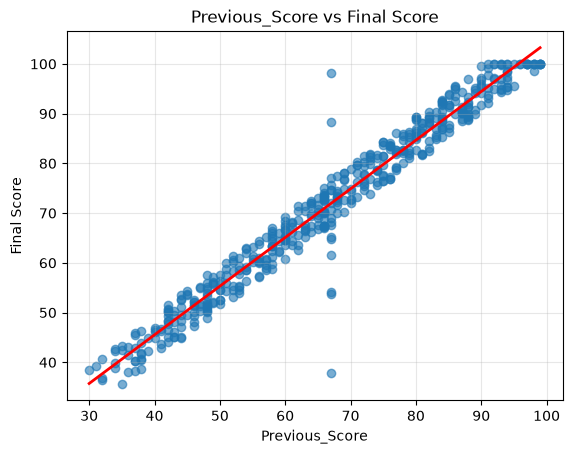

In [34]:
features = ["Hours_Studied", "Attendance", "Previous_Score"]

for feature in features:

    # Scatter plot
    plt.scatter(X[feature], y, alpha=0.6)

    # Calculate regression line
    m, b = np.polyfit(X[feature], y, 1)

    # Regression line
    x_line = np.linspace(X[feature].min(), X[feature].max(), 100)
    y_line = m * x_line + b

    plt.plot(x_line, y_line, linewidth=2, color="red")

    plt.xlabel(feature)
    plt.ylabel("Final Score")
    plt.title(f"{feature} vs Final Score")
    plt.grid(True, alpha=0.3)
    plt.show()

In [35]:

model = LinearRegression()

model.fit(X_train, y_train)


model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Model trained successfully!")

Model trained successfully!


In [36]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("R-Square (R²):", round(r2, 2))

Mean Absolute Error (MAE): 2.08
Mean Squared Error (MSE): 6.33
R-Square (R²): 0.98


In [37]:
joblib.dump(model, "student_score_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [38]:
loaded_model = joblib.load("student_score_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [39]:
new_student = pd.DataFrame({
    "Hours_Studied": [7],
    "Attendance": [94],
    "Previous_Score": [88]
})

prediction = loaded_model.predict(new_student)

print(f"Predicted Final Score: {prediction[0]:.2f}")

Predicted Final Score: 89.87
